# Member 3 — Siriwardena H.A.Y.W.
IT25102977 · CategoricalEncoding

This notebook demonstrates this member’s technique using the shared integrated recipe. Run `group_pipeline.ipynb` for every stage and final exports.

## 01 · Load and inspect the assigned diabetes data

Eight input fields plus target `diabetes`. The reference Framingham columns are not copied.

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))

display(raw.head())
display(raw.dtypes.to_frame("dtype"))
display(raw.describe(include="all").T)

Raw / clean / train / test: 100000 96146 76916 19230


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,dtype
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


## 06 · Member 1 — fit imputations on training only

Numerical median and categorical/binary mode are learned on training rows. They are safety handling for future missing inputs, not a claim that this CSV contained nulls.

In [2]:
preprocessor=make_preprocessor('engineered_bmi_capped')
preprocessor.fit(X_train)
prep=preprocessor.named_steps['prepare']
imputed=prep.impute(X_train)
display(prep.medians_.to_frame('training_median'))
print('Modes:',prep.modes_)
assert imputed.isna().sum().sum()==0
imputed.to_csv(PROJECT_ROOT/'results/outputs/02_train_imputed.csv',index_label='raw_row_id')

Modes: {'gender': 'Female', 'smoking_history': 'never', 'hypertension': np.int64(0), 'heart_disease': np.int64(0)}


,training_median
age,43.00
bmi,27.32
HbA1c_level,5.80
blood_glucose_level,140.00


## 08 · Member 6 — feature engineering after imputation/capping

Fixed age/BMI bands, condition count, and glucose–HbA1c interaction. No target is used. BMI bands are descriptive in this mixed-age dataset, not pediatric/adult clinical diagnoses.

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,age_group,bmi_group,condition_count,glucose_hba1c_interaction
0,Female,80.0,0,1,never,25.19,6.6,140,60_plus,25_to_under_30,1,924.0
1,Female,54.0,0,0,No Info,27.32,6.6,80,40_to_under_60,25_to_under_30,0,528.0
3,Female,36.0,0,0,current,23.45,5.0,155,20_to_under_40,18.5_to_under_25,0,775.0
4,Male,76.0,1,1,current,20.14,4.8,155,60_plus,18.5_to_under_25,2,744.0
6,Female,44.0,0,0,never,19.31,6.5,200,40_to_under_60,18.5_to_under_25,0,1300.0


,size,mean
age_group,,
under_20,15251,0.005442
20_to_under_40,19769,0.024129
40_to_under_60,22807,0.099838
60_plus,19089,0.206873


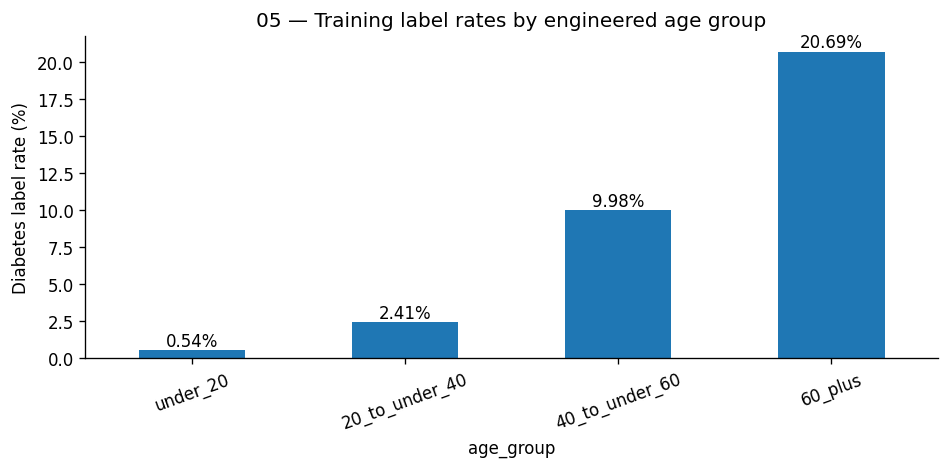

In [3]:
engineered=prep.transform(X_train)
display(engineered.head())
assert np.allclose(engineered.glucose_hba1c_interaction,engineered.blood_glucose_level*engineered.HbA1c_level)
engineered.to_csv(PROJECT_ROOT/'results/outputs/04_train_engineered.csv',index_label='raw_row_id')
rates=engineered.assign(diabetes=y_train).groupby('age_group',observed=True).diabetes.agg(['size','mean']).reindex(['under_20','20_to_under_40','40_to_under_60','60_plus'])
display(rates)
ax=(100*rates['mean']).plot.bar(figsize=(8,4),rot=20);ax.set(ylabel='Diabetes label rate (%)',title='05 — Training label rates by engineered age group')
for c in ax.containers:ax.bar_label(c,fmt='%.2f%%')
savefig(PROJECT_ROOT,'05_engineering_age_rates')

## 09 · Member 3 — one-hot encode nominal fields

No arbitrary integer ordering for gender/smoking. `handle_unknown="ignore"` means unseen categories become all-zero for that feature group.

Learned categories: {'gender': ['Female', 'Male', 'Other'], 'smoking_history': ['No Info', 'current', 'ever', 'former', 'never', 'not current'], 'age_group': ['20_to_under_40', '40_to_under_60', '60_plus', 'under_20'], 'bmi_group': ['18.5_to_under_25', '25_to_under_30', '30_plus', 'under_18.5']}


,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age_group_20_to_under_40,age_group_40_to_under_60,age_group_60_plus,age_group_under_20,bmi_group_18.5_to_under_25,bmi_group_25_to_under_30,bmi_group_30_plus,bmi_group_under_18.5
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


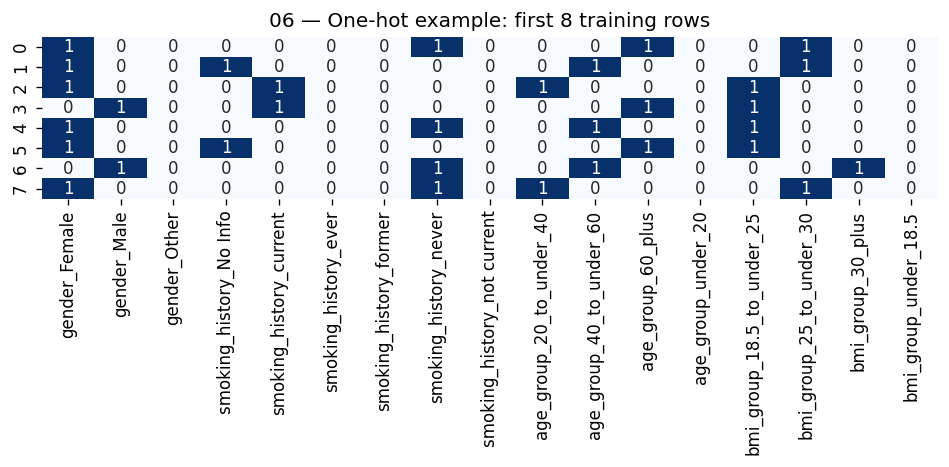

In [4]:
columns=preprocessor.named_steps['columns']
encoder=columns.named_transformers_['categorical']
catcols=categorical_columns(engineered)
encoded=encoder.transform(engineered[catcols])
encoded_names=encoder.get_feature_names_out(catcols)
display(pd.DataFrame(encoded[:8],columns=encoded_names))
print('Learned categories:',dict(zip(catcols,[list(c) for c in encoder.categories_])))
plt.figure(figsize=(8,4));sns.heatmap(pd.DataFrame(encoded[:8],columns=encoded_names),annot=True,fmt='.0f',cmap='Blues',cbar=False);plt.title('06 — One-hot example: first 8 training rows');savefig(PROJECT_ROOT,'06_encoding_heatmap')